# 3. Baboon data: Forberedelse og udforskning

Jeg arbejder med genomiske data fra bavianer (*P. Papio*) baseret på Sørensen et al. (2023). Datasættet indeholder VCF/VCZ-data for kromosom 20 med:

- 227 diploide individer (454 haploide genomer)
- Multiple bavian-arter og populationer

Bavian-arter i datasættet - 6 arter:

- *P. cynocephalus* (Yellow bavian) 
- *P. kindae* (Kinda bavian)   
- *P. anubis* (Olive bavian) 
- *P. papio* (Guinea bavian) 
- *P. ursinus* (Chacma bavian) 
- *P. hamadryas* (Hamadryas bavian)

I denne notebook vil jeg komme ind på følgende:

1. Indlæs og udforsk datasættet
3. Udvælg populationer
4. Beregn derived counts per population
5. Site Frequency Spectrum (SFS) per population
6. Heterozygositet per population 
7. Gem data til efterfølgende notebooks

In [114]:
# Importer nødvendige pakker
# phasic importeres først for at sætte JAX-backend korrekt
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from pathlib import Path
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

DATA_DIR = Path("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR")
OUT_DIR  = Path("output")
OUT_DIR.mkdir(exist_ok=True)

# Biologiske konstanter fra Sørensen et al. 2023
MUT_RATE = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generationstid i år

print("Imports OK")


Imports OK


## Indlæs data

Jeg indlæser genomdata for kromosom 20 fra det fasede VCZ-datasæt. Data er gemt i Zarr-format og håndteres via *sgkit*.

- *sg.load_dataset()* åbner datasættet.
- *sg.count_variant_alleles() tæller antal forekomster af hvert allel per variant (reference- og derived-allel)
- *ac[:, 1]* er derived allele count antal haploide genomer der bærer det alternativt allel. Dette antages at være det derived allel (dvs. ikke-ancestral)
- *nr_samples* er det totale antal haploide genomer per variant (= 2 × antal diploide individer, da data er fasede)

Det derived allele count for et SNP fortæller, hvor mange af de 454 haploide genomer der bærer den nyere variant. Dette er grundlaget for SFS-beregningen.

In [115]:
# loader data for chr20 
ds = sg.load_dataset(DATA_DIR / "chr20.phased.rehead.vcz")

variant_allele_counts = sg.count_variant_alleles(ds) # variant_allele_count har shape (variants, alleles), dtype uint64
ac = variant_allele_counts["variant_allele_count"].values   # triggers compute
nr_samples = ac.sum(axis=1)  # nr haploid samples (chromosomes)

derived_variant_count_df = pd.DataFrame({
    "position": ds["variant_position"].values,
    "derived_count": ac[:, 1],
    "nr_samples": nr_samples,
})
derived_variant_count_df.head()

,position,derived_count,nr_samples
0,19,13,454
1,73,23,454
2,126,1,454
3,148,1,454
4,149,23,454


In [116]:
# Antal varianter og samples
print(f"Antal varianter (chr20):   {len(derived_variant_count_df):,}")
print(f"Totalt haploid sample size: {int(nr_samples.max())}  ({int(nr_samples.max())//2} diploide individer)")

Antal varianter (chr20):   2,665,269
Totalt haploid sample size: 454  (227 diploide individer)


Kromosom 20 fra det fasede VCF-datasæt indeholder 2.665.269 varianter (SNPs) på tværs af 227 diploide individer (454 haploide kromosomer). Hvert individ er repræsenteret med 2 haplotyper, fordi data er fasede.

## Udforsk samples

Sample-ID'erne følger mønsteret *PD_XXXX* (og *Sci_XXXXX* for nogle samples). Jeg tildeler hvert sample til en bavian-art baseret på metadata-tabel fra Sørensen et al. (2023).


In [117]:
# Hent alle sample-ID'er 
sample_ids = ds['sample_id'].values
print(f"Antal samples: {len(sample_ids)}")
print(f"Første 10 sample-ID'er: {sample_ids[:10]}")

Antal samples: 227
Første 10 sample-ID'er: ['Sci_16066' 'Sci_16098' 'Sci_30877' 'Sci_30977' 'Sci_34449' 'Sci_34474'
 'Sci_38168' 'Sci_97074' 'Sci_97124' 'PD_0067']


### Udvælg populationer

Fra Sørensen et al. (2023), Tabel S2: Jeg udfylder listerne med de korrekte sample-ID'er baseret på output ovenfor.

In [118]:
# Udfylder med de korrekte sample-ID'er fra Tabel S2 i artiklen eller fra ds['sample_id'].values ovenfor.

population_map = {
    # P. cynocephalus - Tanzania (Ruaha + Udzungwa + Mahale + Katavi + Selous + Mikumi + Issa Valley)                                                         
    "P_cynocephalus":  ['PD_0213', 'PD_0214', 'PD_0215', 'PD_0216','PD_0217', 'PD_0223',
                         'PD_0224', 'PD_0225', 'PD_0226', 'PD_0227', 'PD_0228', 'PD_0229',
                         'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234', 'PD_0235',
                         'PD_0236', 'PD_0237', 'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232',
                         'PD_0233', 'PD_0234', 'PD_0235', 'PD_0236', 'PD_0237', 'PD_0268',
                         'PD_0269', 'PD_0270', 'PD_0271', 'PD_0272', 'PD_0503', 'PD_0637',
                         'PD_0658', 'PD_0659','PD_0662', 'PD_0687', 'PD_0688', 'PD_0689',
                         'PD_0690', 'PD_0691', 'PD_0745', 'PD_0746', 'PD_0747', 'PD_0748',
                         'PD_0752', 'PD_0753', 'PD_0754', 'PD_0755', 'PD_0756', 'PD_0757',
                         'PD_0761', 'PD_0762', 'PD_0763', 'PD_0764', 'PD_0765', 'PD_0766',
                         'PD_0767', 'PD_0768', 'PD_0769', 'PD_0770', 'PD_0771', 'PD_0772',
                         'PD_0773', 'PD_0774', 'PD_0775'],
    # P. Kindae - Chunga, Zambia      
    "P_kindae":               ['PD_0749','PD_0750','PD_0751', 'PD_0758', 'PD_0759', 'PD_0760',
                            'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779', 'PD_0780', 'PD_0781',
                            'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785', 'PD_0786', 'PD_0787',
                            'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791', 'PD_0792', 'PD_0793',
                            'PD_0794_BAB'],
    # P. Anubis - Tanzania (Lake Manyara, Ngorongoro, Serengeti, Tarangire, Gombe, Arusha), Ethiopia (Gog)
    "P_anubis":         ['PD_0199', 'PD_0200', 'PD_0201', 'PD_0202', 'PD_0203', 'PD_0208',
                            'PD_0209', 'PD_0210', 'PD_0211', 'PD_0212', 'PD_0218', 'PD_0219', 
                            'PD_0220', 'PD_0221', 'PD_0222', 'PD_0238', 'PD_0239', 'PD_0240', 
                            'PD_0241', 'PD_0242', 'PD_0243', 'PD_0244', 'PD_0265', 'PD_0266',
                            'PD_0267', 'PD_0492', 'PD_0493', 'PD_0494', 'PD_0495', 'PD_0496', 
                            'PD_0497', 'PD_0498', 'PD_0499', 'PD_0500', 'PD_0501', 'PD_0502', 
                            'PD_0504', 'PD_0505', 'PD_0506', 'PD_0507', 'PD_0508', 'PD_0509', 
                            'PD_0641', 'PD_0642', 'PD_0649', 'PD_0650', 'PD_0651', 'PD_0652',
                            'PD_0653', 'PD_0654', 'PD_0674', 'PD_0675', 'PD_0676', 'PD_0677', 
                            'PD_0678', 'PD_0679', 'PD_0680', 'PD_0681', 'PD_0682', 'PD_0683', 
                            'PD_0684', 'PD_0685', 'PD_0686', 'PD_0719', 'PD_0720', 'PD_0721', 
                            'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726', 'PD_0727', 
                            'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733', 
                            'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738' 'PD_0739', 
                            'PD_0740', 'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'],
    # P. Papio - Niokolo Koba, Senegal
    "P_papio":          ['PD_0390', 'PD_0391',
                         'PD_0392', 'PD_0393', 'PD_0394', 'PD_0395', 'PD_0396', 'PD_0397', 
                         'PD_0398', 'PD_0399', 'PD_0400', 'PD_0401', 'PD_0397', 'PD_0398', 
                         'PD_0399', 'PD_0400', 'PD_0401'],
    # P. Ursinus (Grayfoot) - Dendro Park, Zambia
    "P_ursinus":        ['PD_0692', 'PD_0693', 'PD_0694', 'PD_0695', 'PD_0695'],
    # P. Hamadryas - Filoha, Ethiopia
    "P_hamadryas":     ['PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701',
                        'PD_0702', 'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707',
                        'PD_0708', 'PD_0709', 'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713',
                        'PD_0714', 'PD_0715', 'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719', 
                        'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
                        'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 
                        'PD_0716', 'PD_0717', 'PD_0718', 'PD_0719'],                            
                                        
}


In [119]:
# Udtrækker subsets 
keep = population_map["P_cynocephalus"]
mask = ds["sample_id"].isin(keep).values
ds_P_cynocephalus = ds.isel(samples=mask)

keep = population_map["P_kindae"]
mask = ds["sample_id"].isin(keep).values
ds_P_kindae = ds.isel(samples=mask)

keep = population_map["P_anubis"]
mask = ds["sample_id"].isin(keep).values
ds_P_anubis = ds.isel(samples=mask)

keep = population_map["P_papio"]
mask = ds["sample_id"].isin(keep).values
ds_P_papio = ds.isel(samples=mask)

keep = population_map["P_ursinus"]
mask = ds["sample_id"].isin(keep).values
ds_P_ursinus = ds.isel(samples=mask)

keep = population_map["P_hamadryas"]
mask = ds["sample_id"].isin(keep).values
ds_P_hamadryas = ds.isel(samples=mask)

print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} samples")
print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} samples")
print(f"Olive baboon: {ds_P_anubis.dims['samples']} samples")
print(f"Guinea baboon: {ds_P_papio.dims['samples']} samples")
print(f"Chacma baboon: {ds_P_ursinus.dims['samples']} samples")
print(f"Hamadryas baboon: {ds_P_hamadryas.dims['samples']} samples")


Yellow baboon: 60 samples
Kinda baboon:  25 samples
Olive baboon: 87 samples
Guinea baboon: 12 samples
Chacma baboon: 4 samples
Hamadryas baboon: 24 samples


/tmp/ipykernel_556231/3383323877.py:26: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Yellow baboon: {ds_P_cynocephalus.dims['samples']} samples")
/tmp/ipykernel_556231/3383323877.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Kinda baboon:  {ds_P_kindae.dims['samples']} samples")
/tmp/ipykernel_556231/3383323877.py:28: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  prin

## Beregn allele counts per population

Jeg beregner derived variant counts (singletons, doubletons, osv.) for hver population.
Disse counts danner grundlaget for SFS analysen og for at fitte coalescent modeller.

In [120]:
def compute_derived_counts(ds_pop, pop_name="population"):
    """
    Beregner derived allele counts for hver population.
    Returnerer en DataFrame med position, derived_count og nr_samples.
    """
    variant_allele_counts = sg.count_variant_alleles(ds_pop)
    ac         = variant_allele_counts["variant_allele_count"].values
    nr_samples = ac.sum(axis=1)

    df = pd.DataFrame({
        "position":  ds_pop["variant_position"].values,
        "derived_count": ac[:, 1],
        "nr_samples": nr_samples,
    })

    # Behold kun segregerende SNPs
    df = df[(df["derived_count"] > 0) & (df["derived_count"] < df["nr_samples"])].copy()
    n  = int(df["nr_samples"].max())
    print(f"{pop_name}: {len(df):,} segregerende SNPs  (n={n} haplotyper = {n//2} individer)")
    return df

df_P_cynocephalus = compute_derived_counts(ds_P_cynocephalus, "Yellow Baboon")
df_P_kindae  = compute_derived_counts(ds_P_kindae,  "Kinda Baboon")
df_P_anubis = compute_derived_counts(ds_P_anubis, "Olive Baboon")
df_P_papio = compute_derived_counts(ds_P_papio, "Guinea Baboon")
df_P_ursinus = compute_derived_counts(ds_P_ursinus, "Chacma Baboon")
df_P_hamadryas = compute_derived_counts(ds_P_hamadryas, "Hamadryas Baboon")


Yellow Baboon: 1,379,280 segregerende SNPs  (n=120 haplotyper = 60 individer)
Kinda Baboon: 833,071 segregerende SNPs  (n=50 haplotyper = 25 individer)
Olive Baboon: 1,096,296 segregerende SNPs  (n=174 haplotyper = 87 individer)
Guinea Baboon: 110,086 segregerende SNPs  (n=24 haplotyper = 12 individer)
Chacma Baboon: 403,120 segregerende SNPs  (n=8 haplotyper = 4 individer)
Hamadryas Baboon: 460,025 segregerende SNPs  (n=48 haplotyper = 24 individer)


In [121]:
df_P_cynocephalus.head()

,position,derived_count,nr_samples
1,73,7,120
2,126,1,120
4,149,22,120
6,236,4,120
7,283,73,120


In [122]:
df_P_kindae.head()

,position,derived_count,nr_samples
1,73,16,50
5,162,4,50
7,283,8,50
19,732,11,50
22,858,8,50


In [123]:
df_P_anubis.head()

,position,derived_count,nr_samples
4,149,1,174
6,236,36,174
7,283,10,174
9,450,3,174
13,501,2,174


In [124]:
df_P_papio.head()

,position,derived_count,nr_samples
0,19,13,24
194,8377,21,24
195,8378,21,24
198,8391,20,24
199,8401,20,24


In [125]:
df_P_ursinus.head()

,position,derived_count,nr_samples
3,148,1,8
17,654,1,8
35,1814,2,8
44,2190,1,8
48,3214,3,8


In [126]:
df_P_hamadryas.head()

,position,derived_count,nr_samples
13,501,17,48
25,953,12,48
40,1971,4,48
42,2144,10,48
43,2189,3,48


## Beregn Site Frequency Spectrum (SFS) per population 


SFS tæller, hvor mange SNPs der er observeret med $1$ kopi, $2$ kopier, $\dots$, $n-1$ kopier af det derived allel. Formen af SFS afspejler populationshistorien fx. viser en overvægt af singletons tegn på vækst eller selektion.

Jeg beregner den foldede SFS (minor allele frequency) for at undgå polariseringsfejl.

In [127]:
def compute_sfs(df, pop_name="population"):
    """Unfoldet SFS fra derived_count DataFrame."""
    n = int(df["nr_samples"].max())
    sfs = np.zeros(n + 1, dtype=int)
    for k, grp in df.groupby("derived_count"):
        k = int(k)
        if 0 < int(k) < n:
            sfs[k] = len(grp)
    return pd.Series(sfs[1:n], index=range(1, n), name=pop_name)

def fold_sfs(sfs):
    """Folder unfoldet SFS til foldet SFS (minor allele frequency)."""
    n = len(sfs) + 1
    mid = n // 2
    folded = sfs.astype(float).copy()
    for i in range(1, mid):
        folded.iloc[i - 1] = sfs.iloc[i - 1] + sfs.iloc[n - i - 1]
    return folded.iloc[:mid]

sfs_P_cynocephalus = compute_sfs(df_P_cynocephalus, "Yellow baboon")
sfs_P_kindae = compute_sfs(df_P_kindae, "Kinda baboon")
sfs_P_anubis = compute_sfs(df_P_anubis, "Olive baboon")
sfs_P_papio = compute_sfs(df_P_papio, "Guinea baboon")
sfs_P_ursinus = compute_sfs(df_P_ursinus, "Chacma Baboon")
sfs_P_hamadryas = compute_sfs(df_P_hamadryas, "Hamadryas baboon")


sfs_P_cynocephalus_f = fold_sfs(sfs_P_cynocephalus)
sfs_P_kindae_f = fold_sfs(sfs_P_kindae)
sfs_P_anubis_f = fold_sfs(sfs_P_anubis)
sfs_P_papio_f = fold_sfs(sfs_P_papio)
sfs_P_ursinus_f = fold_sfs(sfs_P_ursinus)
sfs_P_hamadryas_f = fold_sfs(sfs_P_hamadryas)


In [128]:
print("Yellow baboon foldet SFS (første 8 bins):")
print(sfs_P_cynocephalus_f.head(8))

Yellow baboon foldet SFS (første 8 bins):
1    287427.0
2    168509.0
3    113467.0
4     82232.0
5     64245.0
6     50982.0
7     43618.0
8     36639.0
Name: Yellow baboon, dtype: float64


In [129]:
print("Kinda baboon foldet SFS (Første 8 bins):")
print(sfs_P_kindae_f.head(8))

Kinda baboon foldet SFS (Første 8 bins):
1    133541.0
2     84438.0
3     71922.0
4     58685.0
5     50041.0
6     41981.0
7     37256.0
8     35686.0
Name: Kinda baboon, dtype: float64


In [130]:
print("Olive baboon foldet SFS (første 8 bins):")
print(sfs_P_anubis_f.head(8))

Olive baboon foldet SFS (første 8 bins):
1    217244.0
2    129008.0
3     82881.0
4     65301.0
5     50738.0
6     41406.0
7     33328.0
8     27022.0
Name: Olive baboon, dtype: float64


In [131]:
print("Guinea baboon foldet SFS (første 8 bins):")
print(sfs_P_papio_f.head(8))

Guinea baboon foldet SFS (første 8 bins):
1    13944.0
2    12248.0
3    10487.0
4    10779.0
5     9600.0
6     7575.0
7     9487.0
8     9319.0
Name: Guinea baboon, dtype: float64


In [132]:
print("Chacma baboon foldet SFS (første 8 bins):")
print(sfs_P_ursinus_f.head(8))

Chacma baboon foldet SFS (første 8 bins):
1    149888.0
2    127800.0
3     84659.0
4     40773.0
Name: Chacma Baboon, dtype: float64


In [133]:
print("Hamadryas baboon foldet SFS (første 8 bins):")
print(sfs_P_hamadryas_f.head(8))

Hamadryas baboon foldet SFS (første 8 bins):
1    68203.0
2    44146.0
3    32840.0
4    25939.0
5    24459.0
6    21338.0
7    21855.0
8    17906.0
Name: Hamadryas baboon, dtype: float64


### Normaliseret SFS og Tajima's D

Tajima's $D$ er en statistiks størrelse der sammenligner to estimater af $\theta = 4N_e\mu$:

- $\hat{\theta}_\pi$: Estimeret fra gennemsnitlig pairwise difference
- $\hat{\theta}_W$ (Watterson's estimator): Estimeret fra antal segregerende sites

$$D = \frac{\hat{\theta}_\pi - \hat{\theta}_W}{\text{Std}(\hat{\theta}_\pi - \hat{\theta}_W)}$$

- $D \approx 0$: Data passer til neutral coalescent med konstant N
- $D < 0$: Overskud af sjældne varianter (ekspansion eller rensende selektion)
- $D > 0$: Overskud af intermediære varianter (flaskehals eller balancerende selektion)

In [ ]:
# Tajima's D sammenligner pi (pairwise diversity) med Watterson's theta
pop_names = {
    "Yellow Baboon": (df_P_cynocephalus, sfs_P_cynocephalus, "C1"),
    "Kinda Baboon":  (df_P_kindae, sfs_P_kindae, "C2"),
    "Olive Baboon":  (df_P_anubis, sfs_P_anubis, "C3"),
    "Guinea Baboon": (df_P_papio, sfs_P_papio, "C4"),
    "Chacma Baboon": (df_P_ursinus, sfs_P_ursinus, "C5"),
    "Hamadryas Baboon": (df_P_hamadryas, sfs_P_hamadryas, "C6"), 
}

def tajimas_d(df_pop, n=4):
    """
    Beregner Tajima's D for en population.
    Kræver derived count data og subsampler til n haplotyper.
    """
    rng = np.random.default_rng(0)
    ngood = df_pop["derived_count"].values.astype(int)
    nbad = (df_pop["nr_samples"] - df_pop["derived_count"]).values.astype(int)

    k = rng.hypergeometric(
        ngood=ngood,
        nbad=nbad,
        nsample=n,
    )
    k = k[(k > 0) & (k < n)]
    S = len(k)  # antal segregerende sites

    if S == 0:
        return np.nan, np.nan, np.nan

    # Watterson's theta_W = S / a1
    a1 = sum(1/i for i in range(1, n))
    theta_W = S / a1

    # Pi (gennemsnitlig pairwise differences)
    pi_val = sum(ki * (n - ki) for ki in k) * 2 / (n * (n-1))

    b1 = (n + 1) / (3 * (n - 1))
    b2 = (2 * (n**2 + n + 3)) / (9 * n * (n - 1))
    c1 = b1 - 1/a1
    a2 = sum(1/i**2 for i in range(1, n))
    c2 = b2 - (n + 2)/(a1 * n) + a2/a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)
    var_d = e1 * S + e2 * S * (S - 1)
    D = (pi_val - theta_W) / np.sqrt(var_d) if var_d > 0 else np.nan

    return D, pi_val, theta_W

tajima_results = {}
for name, (df_pop, _, _) in pop_names.items():
    D, pi_v, theta_w = tajimas_d(df_pop)
    tajima_results[name] = {"Tajima's D": round(D, 4), "pi": round(pi_v, 6), "theta_W": round(theta_w, 6)}

tajima_df = pd.DataFrame(tajima_results).T
print("Tajima's D per population:")
print(tajima_df)
print()
print("Fortolkning:")
print("  D ≈ 0:  konsistent med neutral evolution og konstant population")
print("  D > 0:  overskud af common variants (admixture, balancerende selektion, bottleneck)")
print("  D < 0:  overskud af singletons (nylig ekspansion, purifying selektion)")

Tajima's D per population:
                  Tajima's D             pi        theta_W
Yellow Baboon        -0.0797  212447.500000  214070.181818
Kinda Baboon          0.0035  201368.333333  201301.090909
Olive Baboon         -0.0964  149131.333333  150511.090909
Guinea Baboon         0.1401   36934.500000   36448.909091
Chacma Baboon         0.0518  160831.166667  160042.909091
Hamadryas Baboon      0.0614  122041.166667  121333.090909

Fortolkning:
  D ≈ 0:  konsistent med neutral evolution og konstant population
  D > 0:  overskud af common variants (admixture, balancerende selektion, bottleneck)
  D < 0:  overskud af singletons (nylig ekspansion, purifying selektion)


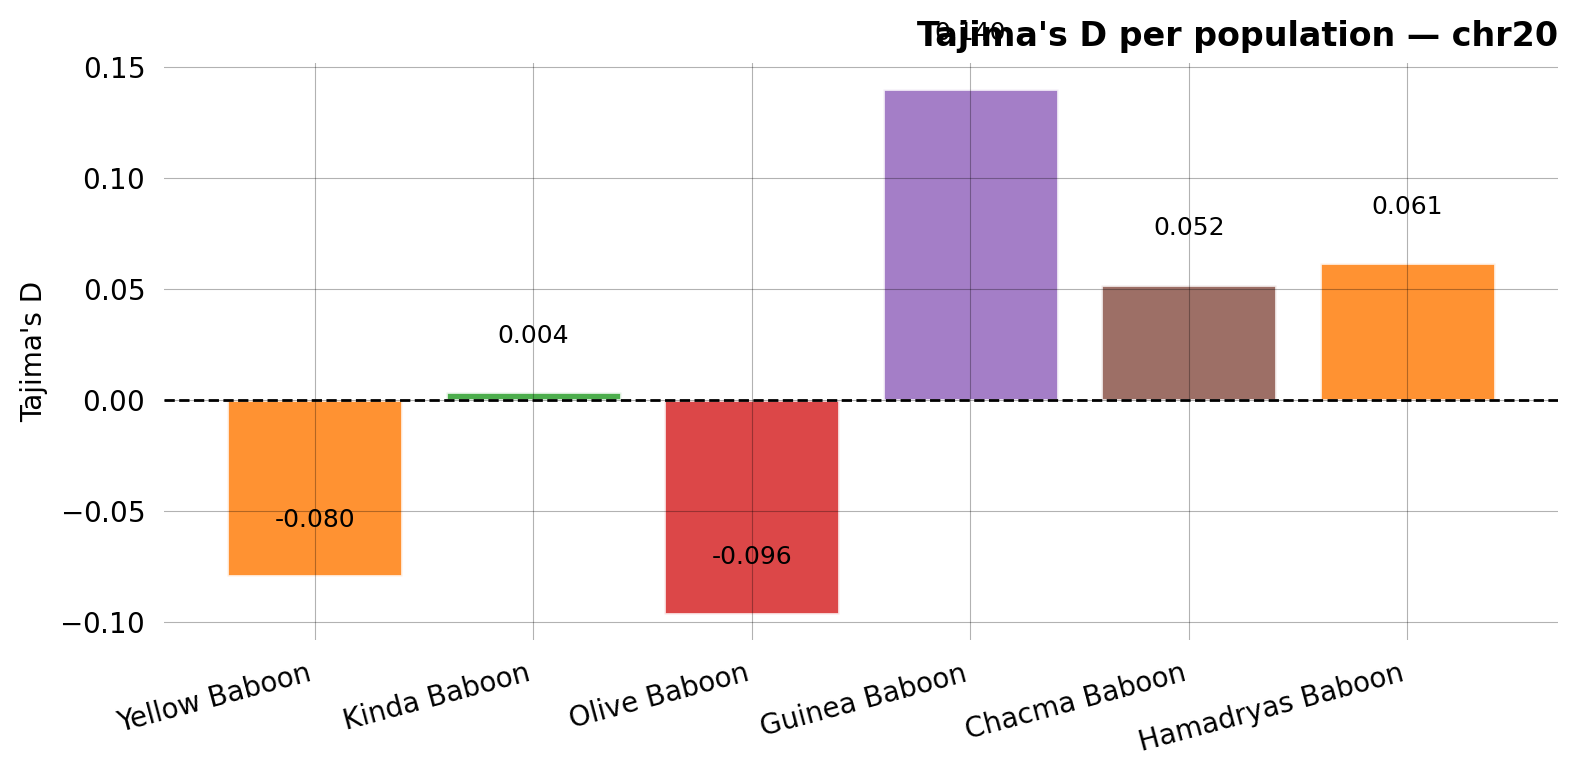

In [138]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["C1", "C2", "C3", "C4", "C5"]
bars = ax.bar(tajima_df.index, tajima_df["Tajima's D"], color=colors, alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_ylabel("Tajima's D")
ax.set_title("Tajima's D per population — chr20", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, tajima_df["Tajima's D"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [139]:
summary = pd.DataFrame({
    "pi": pi_df["pi"],
    "Ne_ref": (pi_df["pi"] / (4 * MUT_RATE)).astype(int),
    "Tajima's D": tajima_df["Tajima's D"],
})
print("Samlet overblik per population:")
print(summary.round(6))

Samlet overblik per population:
                        pi  Ne_ref  Tajima's D
Yellow Baboon     0.002922   81160     -0.0797
Kinda Baboon      0.002737   76032      0.0035
Olive Baboon      0.002053   57038     -0.0964
Guinea Baboon     0.000491   13625      0.1401
Chacma Baboon     0.001954   54279      0.0518
Hamadryas Baboon  0.001657   46019      0.0614


## Heterozygositet

Artiklen siger at heterozygositet er fra 0.0006–0.0029 på tværs af de 19 lokaliteter.

In [134]:
def compute_pi(df):
    k  = df["derived_count"].values
    n  = df["nr_samples"].values
    L  = int(df["position"].max() - df["position"].min())
    return (2 * (k / n) * ((n - k) / n)).sum() / L


pi_df = pd.DataFrame({
    "pi": {
        "Yellow Baboon": compute_pi(df_P_cynocephalus),
        "Kinda Baboon": compute_pi(df_P_kindae),
        "Olive Baboon": compute_pi(df_P_anubis),
        "Guinea Baboon": compute_pi(df_P_papio),
        "Chacma Baboon": compute_pi(df_P_ursinus),
        "Hamadryas Baboon": compute_pi(df_P_hamadryas),
    }
})

print(pi_df.round(6))

                        pi
Yellow Baboon     0.002922
Kinda Baboon      0.002737
Olive Baboon      0.002053
Guinea Baboon     0.000491
Chacma Baboon     0.001954
Hamadryas Baboon  0.001657


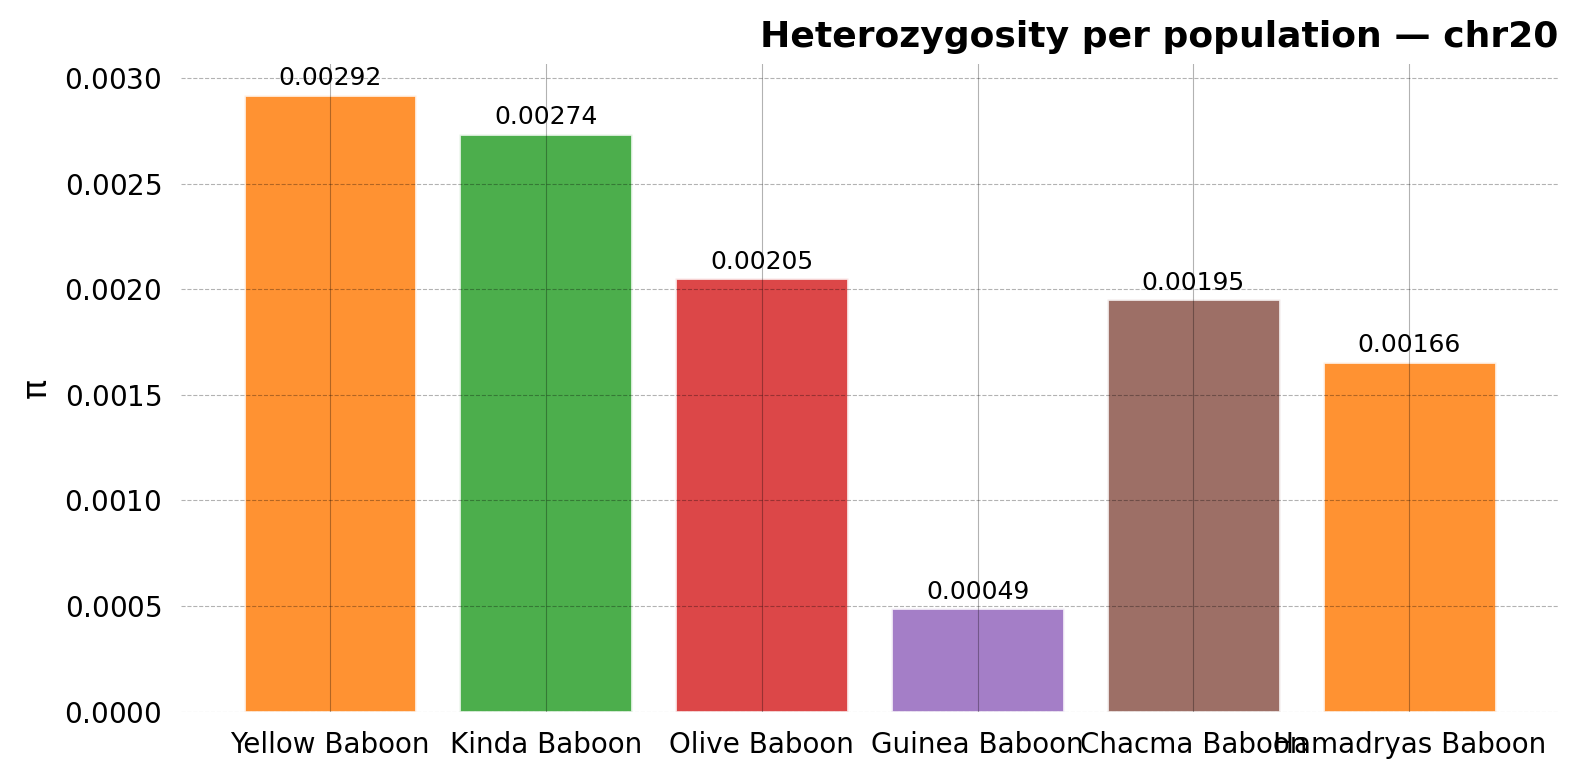

In [135]:
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['C1', 'C2', 'C3', 'C4', 'C5']
bars    = ax.bar(pi_df.index, pi_df["pi"], color=colors, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, pi_df["pi"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.00002,
            f"{val:.5f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("π", fontsize=12)
ax.set_title("Heterozygosity per population — chr20",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Forventet vs. observeret SFS per population 

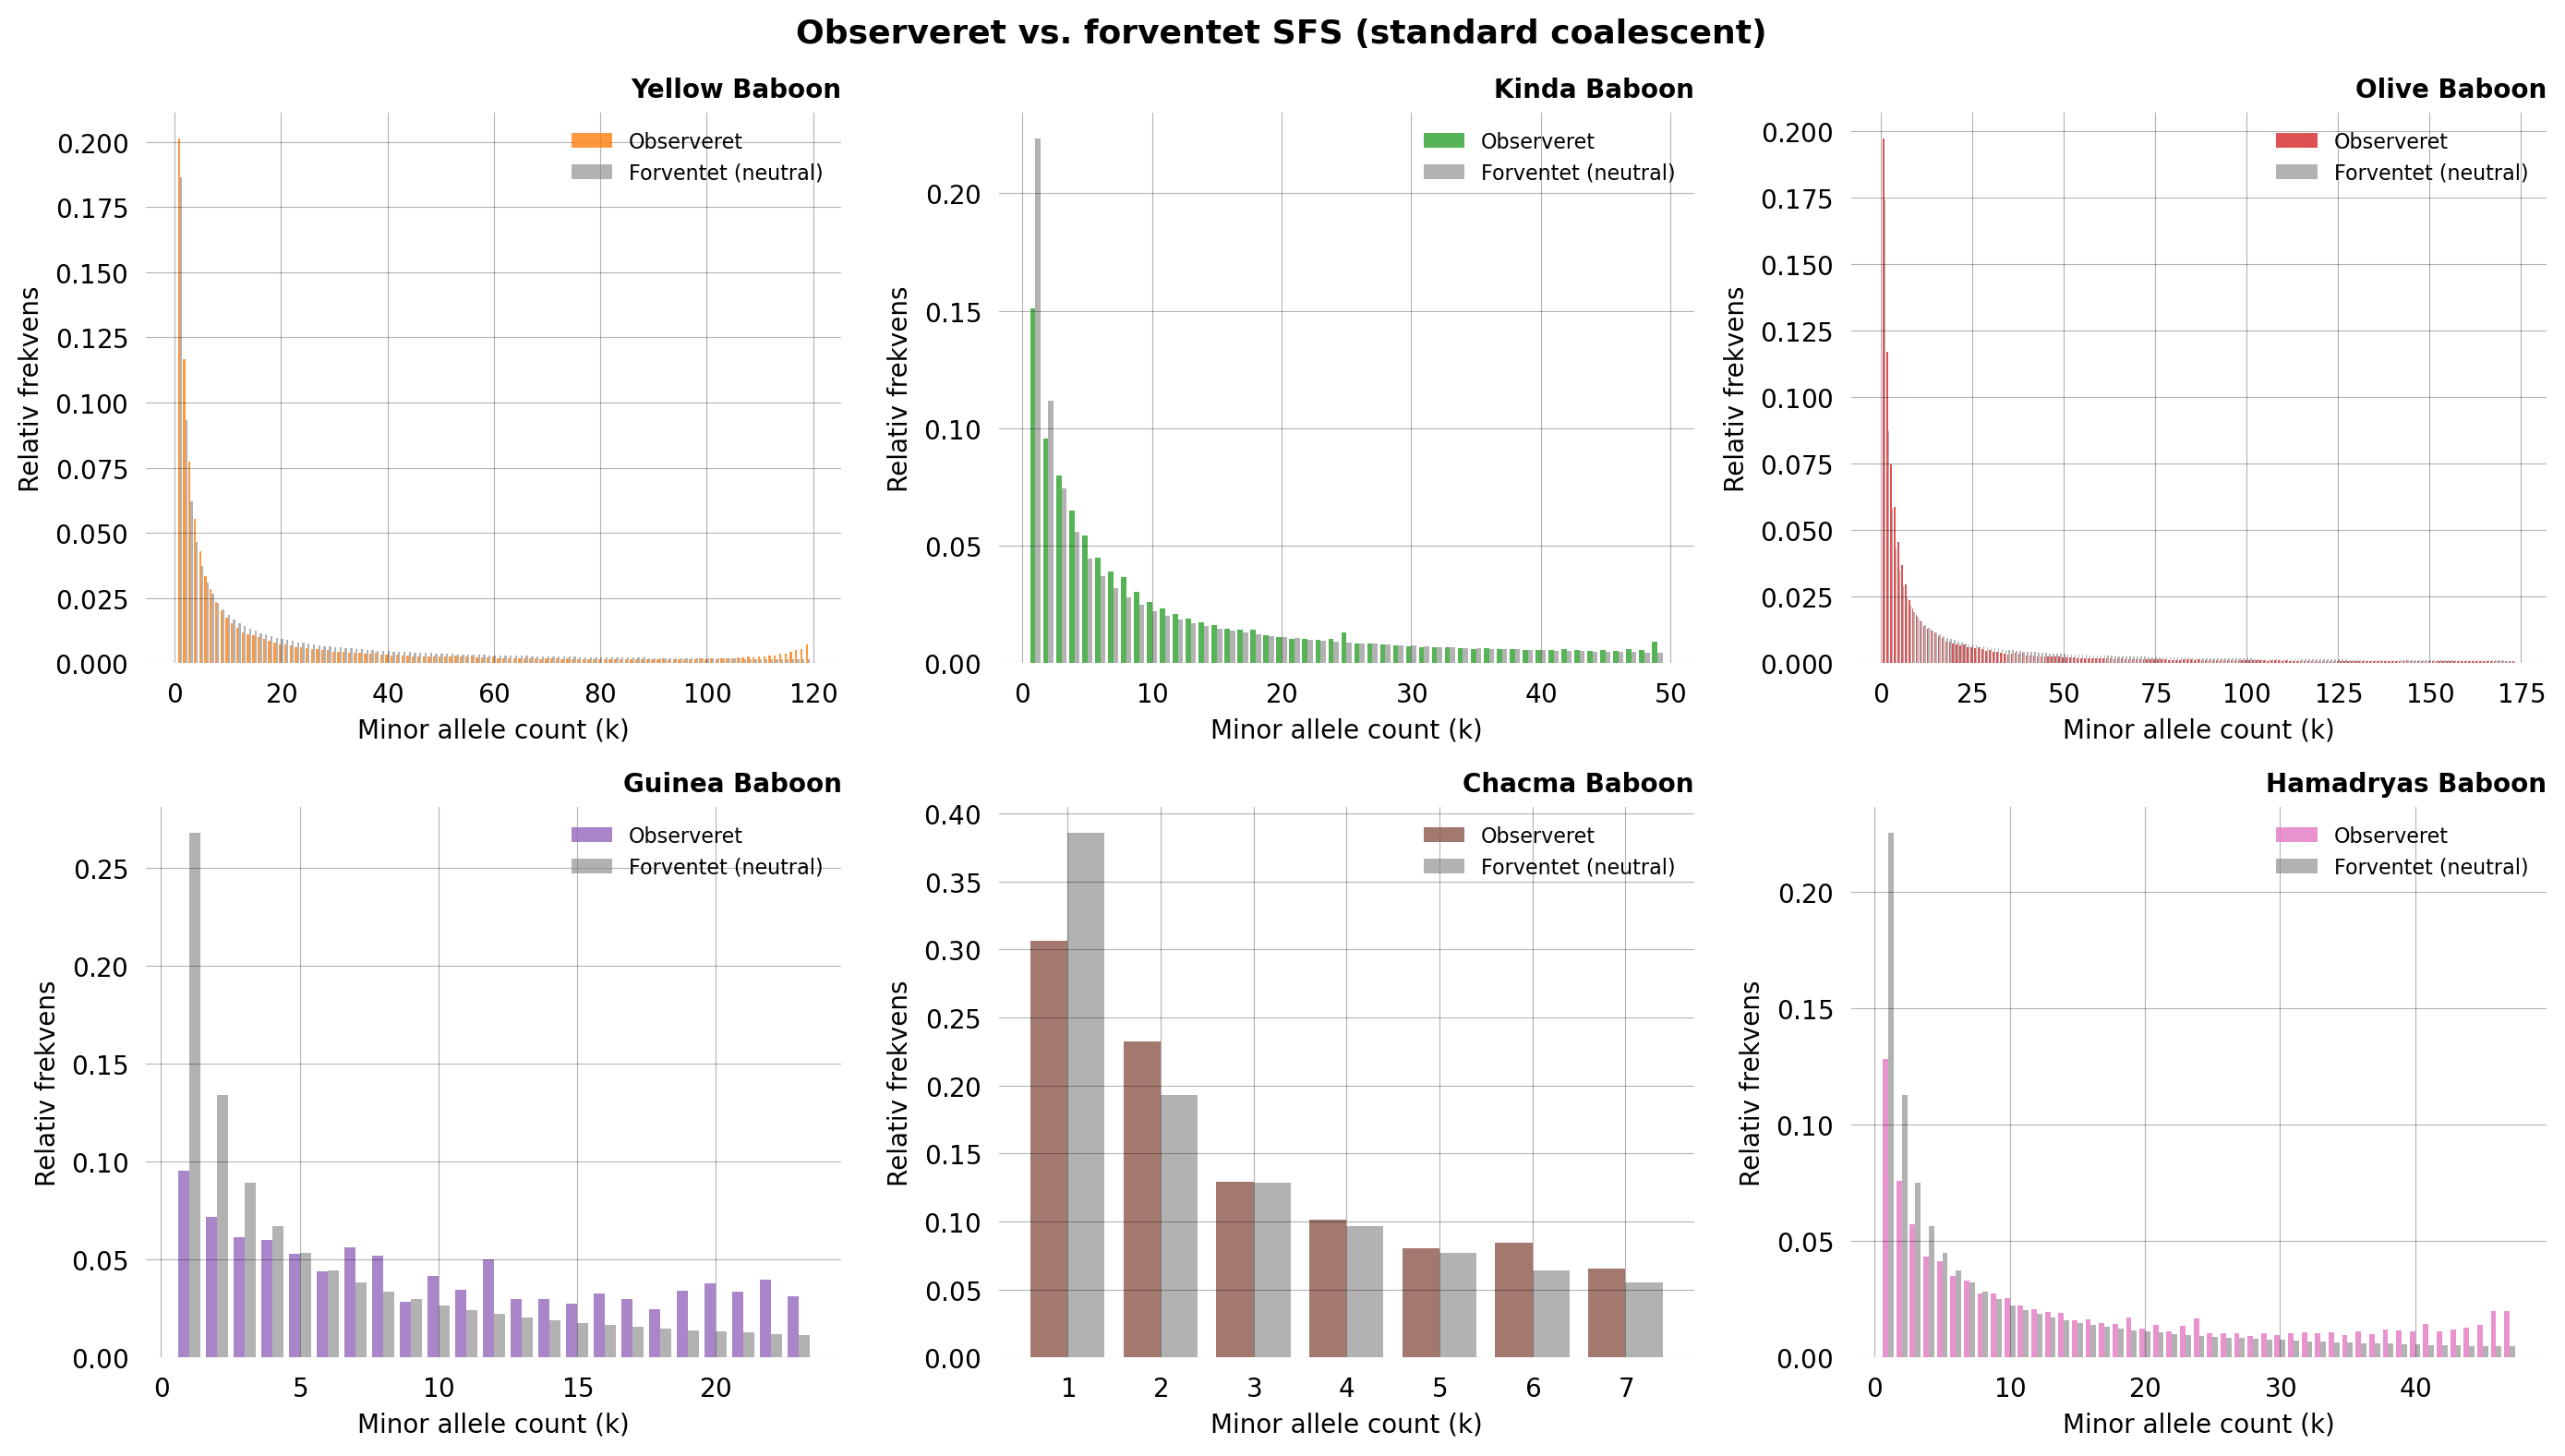

In [136]:
# For hver population: fitter theta med MoM og sammenlign forventet SFS med observeret
pop_names = {
    "Yellow Baboon": (df_P_cynocephalus, sfs_P_cynocephalus, "C1"),
    "Kinda Baboon":  (df_P_kindae, sfs_P_kindae, "C2"),
    "Olive Baboon":  (df_P_anubis, sfs_P_anubis, "C3"),
    "Guinea Baboon": (df_P_papio, sfs_P_papio, "C4"),
    "Chacma Baboon": (df_P_ursinus, sfs_P_ursinus, "C5"),
    "Hamadryas Baboon": (df_P_hamadryas, sfs_P_hamadryas, "C6"), 
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

pop_items = list(pop_names.items())
for ax_idx, (name, (df_pop, sfs_obs, color)) in enumerate(pop_items):
    ax = axes[ax_idx]
    pi_val = pi_df.loc[name, "pi"]
    Ne_ref = pi_val / (4 * MUT_RATE)

    theta_pi = pi_val  # pi ≈ theta for panmiktisk population

    x = np.arange(1, len(sfs_obs) + 1)
    # Normaliser begge til frekvenser
    obs_norm = sfs_obs.values / sfs_obs.values.sum()
    exp_sfs = np.array([1/k for k in x])
    exp_norm = exp_sfs / exp_sfs.sum()

    ax.bar(x - 0.2, obs_norm, width=0.4, label="Observeret", color=color, alpha=0.8)
    ax.bar(x + 0.2, exp_norm, width=0.4, label="Forventet (neutral)", color="grey", alpha=0.6)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Minor allele count (k)")
    ax.set_ylabel("Relativ frekvens")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Observeret vs. forventet SFS (standard coalescent)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Gem data

Jeg gemmer de beregnede DataFrames som CSV-filer, så jeg i de næste notebooks kan indlæse dem direkte uden at genkøre det hele igen.

In [140]:
df_P_cynocephalus.to_csv(OUT_DIR / "derived_counts_P_cynocephalus.csv", index=False)
df_P_kindae.to_csv(OUT_DIR / "derived_counts_P_kindae.csv",       index=False)
df_P_anubis.to_csv(OUT_DIR / "derived_counts_P_anubis.csv", index=False)
df_P_papio.to_csv(OUT_DIR / "derived_counts_P_papio.csv", index=False)
df_P_ursinus.to_csv(OUT_DIR / "derived_counts_P_ursinus.csv", index=False)
df_P_hamadryas.to_csv(OUT_DIR / "derived_counts_P_hamadryas.csv", index=False)

sfs_P_cynocephalus_f.to_csv(OUT_DIR / "sfs_folded_P_cynocephalus.csv",  header=True)
sfs_P_kindae_f.to_csv(OUT_DIR / "sfs_folded_P_kindae.csv",         header=True)
sfs_P_anubis_f.to_csv(OUT_DIR / "sfs_folded_P_anubis.csv",  header=True)
sfs_P_papio_f.to_csv(OUT_DIR / "sfs_folded_P_papio.csv",  header=True)
sfs_P_ursinus_f.to_csv(OUT_DIR / "sfs_folded_P_ursinus.csv",  header=True)
sfs_P_hamadryas_f.to_csv(OUT_DIR / "sfs_folded_P_hamadryas.csv",  header=True)

pi_df.to_csv(OUT_DIR / "pi_per_population.csv")

print("Gemte filer:")
for f in sorted(OUT_DIR.iterdir()):
    print(" ", f.name)

Gemte filer:
  derived_counts_P_anubis.csv
  derived_counts_P_cynocephalus.csv
  derived_counts_P_hamadryas.csv
  derived_counts_P_kindae.csv
  derived_counts_P_papio.csv
  derived_counts_P_ursinus.csv
  pi_per_population.csv
  sfs_folded_P_anubis.csv
  sfs_folded_P_cynocephalus.csv
  sfs_folded_P_hamadryas.csv
  sfs_folded_P_kindae.csv
  sfs_folded_P_papio.csv
  sfs_folded_P_ursinus.csv
